# EFO Transcript Clustering Pipeline
**Goal:** Identify the most common concerns of ALICE vs. Above ALICE community members from focus group transcripts.

**Pipeline overview:**
1. Load & parse transcripts → speaker-level rows (role = unknown)
2. LLM: role detection — facilitator vs. participant (facilitators removed)
3. LLM: 5-vote ALICE classification — 3+ votes needed to accept, else Cannot Determine
4. LLM: concern extraction per speaker
5. Explode concerns → one row per concern
6. Embed ALL concerns with nomic-embed-text
7. UMAP dimensionality reduction
8. HDBSCAN clustering on full dataset
9. LLM-named clusters + word cloud sanity check
10. 2D UMAP visualization colored by ALICE class
11. Save full clustering outputs
12. Cluster composition analysis — ALICE vs. Above ALICE per cluster
13. LLM comparative summary

## 0. Imports & Configuration

In [17]:
import os
import re
import json
import time
import ollama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics import adjusted_rand_score, silhouette_score
import umap
import hdbscan

# ── Configuration ─────────────────────────────────────────────────────────────
TRANSCRIPTS_DIR     = "../data"       # folder containing all .txt files
OLLAMA_MODEL        = "qwen2.5:14b"        # classification + concern extraction + cluster naming
EMBED_MODEL         = "nomic-embed-text"   # embeddings

# Classification
N_VOTES             = 5                    # number of classification runs per speaker
MIN_VOTES_TO_ACCEPT = 3                    # minimum agreeing votes to accept a label

# UMAP
UMAP_N_COMPONENTS   = 5                    # dimensions for HDBSCAN input
UMAP_N_COMPONENTS_2D = 2                   # dimensions for visualization
UMAP_METRIC         = "cosine"
UMAP_RANDOM_STATE   = 42

# HDBSCAN — keep small given ~150-300 row dataset
HDBSCAN_MIN_CLUSTER_SIZE = 3
HDBSCAN_MIN_SAMPLES      = 2

print("Configuration loaded.")


# ── Shared LLM utility — available to all cells ───────────────────────────────
def call_ollama_with_retry(prompt, temperature, retries=3):
    """Call Ollama chat with exponential backoff on failure.

    Defined here in Cell 0 so it is available to role detection (Cell 2),
    classification (Cell 3), and concern extraction (Cell 4) without
    any cell needing to import or redefine it.

    Returns the raw JSON string, or None if all retries fail.
    """
    for attempt in range(retries):
        try:
            response = ollama.chat(
                model=OLLAMA_MODEL,
                messages=[{"role": "user", "content": prompt}],
                format="json",
                options={"temperature": temperature},
            )
            raw = response["message"]["content"].strip()
            raw = re.sub(r"^```json\s*|^```\s*|\s*```$", "", raw, flags=re.MULTILINE).strip()
            return raw
        except Exception as e:
            wait = 2 ** attempt   # 1s, 2s, 4s
            print(f"  Ollama call failed (attempt {attempt + 1}/{retries}): {e} — retrying in {wait}s")
            time.sleep(wait)
    print("  All retries exhausted — returning None")
    return None

Configuration loaded.


## 1. Parse Transcripts → Speaker-Level Dataframe
Each row = one speaker in one transcript.  
Transcripts without `Speaker N` markers are skipped.

In [2]:
SPEAKER_LINE = re.compile(r"^Speaker \d+\s*$", re.MULTILINE)


def has_speaker_markers(text):
    """Check if a transcript has any Speaker N markers."""
    return bool(SPEAKER_LINE.search(text))


def parse_header(text):
    """Extract metadata from the top section of a transcript.

    Reads lines until the first standalone 'Speaker N' line.
    Lines containing ':' are parsed as key-value pairs.
    """
    header = {}
    for line in text.split("\n"):
        if SPEAKER_LINE.match(line.strip()):
            break
        if ":" in line:
            key, _, val = line.partition(":")
            header[key.strip()] = val.strip()
    return header


def extract_population_tags(header):
    """Pull actual demographic tags from the Population line.

    Handles two key variants found in the wild:
      - Full template key: 'Population - identify one or more of the following groups'
      - Short key:         'Population'

    For the full template key, actual tags appear after 'White/BIPOC,' in the
    comma-separated list. For the short key, the value is used as-is.
    """
    # Try full template key first, fall back to short key
    pop_line = (
        header.get("Population - identify one or more of the following groups", "")
        or header.get("Population", "")
    )
    if not pop_line:
        return ""

    # For the template format, strip the boilerplate options before White/BIPOC
    parts = pop_line.split(",")
    actual_tags, found_bipoc = [], False
    for p in parts:
        if "white/bipoc" in p.lower():
            found_bipoc = True
            continue
        if found_bipoc:
            actual_tags.append(p.strip())
    # If we found tags after White/BIPOC, use them; otherwise return the raw value
    return ", ".join(actual_tags) if actual_tags else pop_line


def parse_speakers(text):
    """Split transcript body into per-speaker utterance lists.

    The body starts at the first Speaker N line.
    Only called after has_speaker_markers() confirms markers exist.
    """
    first_speaker = SPEAKER_LINE.search(text)
    body          = text[first_speaker.start():]
    matches       = list(SPEAKER_LINE.finditer(body))

    speakers = {}
    for i, m in enumerate(matches):
        speaker   = m.group(0).strip()
        start     = m.end()
        end       = matches[i + 1].start() if i + 1 < len(matches) else len(body)
        utterance = body[start:end].strip()
        if utterance:
            speakers.setdefault(speaker, []).append(utterance)
    return speakers


def build_speaker_dataframe(transcripts_dir):
    """Load all transcripts and build one row per speaker.

    Gate: has_speaker_markers() is checked first.
    Note: each .txt file must contain exactly one transcript session.
    Files containing two concatenated sessions must be split before running.
    """
    rows, skipped = [], []

    for filepath in sorted(Path(transcripts_dir).glob("*.txt")):
        text = filepath.read_text(encoding="utf-8", errors="ignore")

        if not has_speaker_markers(text):
            skipped.append(filepath.name)
            continue

        header   = parse_header(text)
        speakers = parse_speakers(text)
        pop_tags = extract_population_tags(header)

        for speaker_id, utterances in speakers.items():
            full_text = " ".join(utterances).strip()
            if not full_text:
                continue
            rows.append({
                "filename":        filepath.name,
                "date":            header.get("Date of conversation", ""),
                "location":        header.get("Meeting location", ""),
                "facilitator":     header.get("Name of Facilitator(s)", ""),
                "attendees":       header.get("Number of attendees", ""),
                "population_tags": pop_tags,
                "speaker_id":      speaker_id,
                "speaker_role":    "unknown",
                "full_text":       full_text,
            })

    df = pd.DataFrame(rows)
    print(f"Loaded {df['filename'].nunique()} transcripts → {len(df)} speaker rows")
    print(f"Skipped {len(skipped)} unlabeled transcripts: {skipped}")
    return df


df_speakers = build_speaker_dataframe(TRANSCRIPTS_DIR)
df_speakers.head()


Loaded 23 transcripts → 185 speaker rows
Skipped 8 unlabeled transcripts: ['EFO_75 State Street__Cumberland County, Older Adults, Urban, Above ALICE.txt', 'EFO_DECDSubcommittee_Both Counties, Urban, Above ALICE.txt', 'EFO_Investment Vol_Cumberland County, Urban, Above ALICE, UWSM Volunteers.txt', 'EFO_Loaned Execs_Cumberland County, Corporate Employees, Above ALICE, UWSM Volunteers.txt', 'EFO_Noble Students and Ambassadors 1_York, Rural, Under 25, Most ALICE.txt', 'EFO_Noble Students and Ambassadors 2_York, Rural, Under 25, Most ALICE.txt', 'EFO_Noble Teachers 3_York, Rural.txt', 'EFO_WomenUnited-11-19-2025 -Karen- FINAL.txt']


,filename,date,location,facilitator,attendees,population_tags,speaker_id,speaker_role,full_text
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",3/17/26,OOB,Pamela Bennett,8,,Speaker 1,unknown,"This is Pamela, and it's March 17, and I am at..."
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",3/17/26,OOB,Pamela Bennett,8,,Speaker 2,unknown,School System. The school system is specific t...
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",3/17/26,OOB,Pamela Bennett,8,,Speaker 3,unknown,I think the police department and fire departm...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",3/17/26,OOB,Pamela Bennett,8,,Speaker 4,unknown,"No Everybody minds their own business, but the..."
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",3/17/26,OOB,Pamela Bennett,8,,Speaker 6,unknown,"There's a lot of places to go walking, if you ..."


## 2. LLM Role Detection — Facilitator vs. Participant
One LLM call per speaker to determine whether they are the session facilitator
or a community member participant.

Facilitators are **fully removed** before any classification or embedding —
their summarizing language would otherwise contaminate participant clusters.

Results are saved to `df_speakers.csv` as a checkpoint.

In [3]:
ROLE_DETECTION_PROMPT = """\
This is a transcript excerpt from a community focus group in Southern Maine.
Determine whether this speaker is the SESSION FACILITATOR, a COMMUNITY PARTICIPANT,
or a SERVICE PROVIDER (professional describing their clients, not their own situation).

Signals of a FACILITATOR:
- Asks structured questions to the group
- Transitions between topics ("let's move on to...", "the next question is...")
- Summarizes or reflects back what others said
- Mentions United Way or the organizing body
- Introduces the session or wraps it up
- Thanks participants or explains the process

Signals of a SERVICE PROVIDER:
- Describes the needs or struggles of the people they serve (clients, students, families)
- Speaks from a professional role (social worker, coordinator, teacher, caseworker)
- Uses language like "the families we work with", "our students", "the people I help"
- Discusses community problems from an observational/professional standpoint
- Does NOT describe their own financial struggles as lived experience

Signals of a COMMUNITY PARTICIPANT:
- Shares personal experiences or opinions
- Raises personal concerns about housing, food, health, costs etc.
- Responds to questions with their own views
- Talks about their own life situation

SPEAKER TEXT:
{full_text}

Return ONLY valid JSON, no explanation, no markdown:
{{\"role\": \"facilitator\"}}
or
{{\"role\": \"participant\"}}
or
{{\"role\": \"service_provider\"}}
"""


def detect_role(row):
    """Single LLM call to classify a speaker as facilitator, participant, or service_provider.

    Returns 'facilitator', 'participant', 'service_provider', or 'unknown' on failure.
    """
    raw = call_ollama_with_retry(
        prompt=ROLE_DETECTION_PROMPT.format(full_text=row["full_text"]),
        temperature=0,
    )
    if raw is None:
        return "unknown"
    try:
        parsed = json.loads(raw)
        assert parsed["role"] in ["facilitator", "participant", "service_provider"]
        return parsed["role"]
    except Exception:
        return "unknown"


def run_role_detection(df, delay=0.3):
    """Detect role for every speaker row.

    'unknown' is treated conservatively as participant.
    Facilitators and service_providers are both excluded before classification.
    """
    roles = []
    for i, row in df.iterrows():
        role = detect_role(row)
        roles.append(role)
        print(f"[{i}] {row['filename']} | {row['speaker_id']} → {role}")
        time.sleep(delay)

    df = df.copy()
    df["speaker_role"] = roles
    return df


df_speakers = run_role_detection(df_speakers)
df_speakers.to_csv("df_speakers.csv", index=False)

print(f"\nFacilitators detected      : {(df_speakers['speaker_role'] == 'facilitator').sum()}")
print(f"Participants detected       : {(df_speakers['speaker_role'] == 'participant').sum()}")
print(f"Service providers detected  : {(df_speakers['speaker_role'] == 'service_provider').sum()}")
print(f"Unknown (kept as participant): {(df_speakers['speaker_role'] == 'unknown').sum()}")
print("\nFacilitators and service providers will be excluded before classification.")
df_speakers.groupby(["filename", "speaker_id", "speaker_role"]).size().reset_index(name="utterances").head(20)


[0] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 1 → facilitator
[1] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 2 → participant
[2] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 3 → participant
[3] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 4 → participant
[4] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 6 → participant
[5] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 8 → participant
[6] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 5 → participant
[7] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 7 → participant
[8] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 10 → participant
[9] EFO_Bartlett Woods_York County, Older Adults, Urban, ALICE.txt | Speaker 1 → facilitator
[10] EFO_Bartlett Woods_York County, Older Adults, Urban, ALICE.txt | Speaker 2 → participant
[11] EFO_Bartlett Woods_York County, Older Adults, Urban, ALICE.t

,filename,speaker_id,speaker_role,utterances
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,facilitator,1
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 10,participant,1
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,participant,1
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,participant,1
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,participant,1
5,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 5,participant,1
6,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,participant,1
7,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 7,participant,1
8,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 8,participant,1
9,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 1,facilitator,1


## 3. LLM Classification — 5-Vote Consensus
Each **participant** speaker is classified 5 times independently.  
- **3 or more votes agree on ALICE or Above ALICE** → auto-accepted  
- **Neither label reaches 3 votes** → `Cannot Determine` — excluded downstream, no human review

Facilitator rows are fully skipped — removed in Cell 2.

Two possible output labels: `ALICE` and `Above ALICE`.  
`Cannot Determine` is used when votes are genuinely split or insufficient.

In [4]:
CLASSIFICATION_PROMPT = """\
You are analyzing a transcript excerpt from a community focus group in Southern Maine.
Classify the speaker as ALICE or Above ALICE using ALL available signals —
direct, indirect, and contextual. You do not need explicit financial statements
to make a classification.

DEFINITIONS:
- ALICE: Asset Limited, Income Constrained. Includes people below the poverty line
  and working people who struggle to afford basic needs (housing, food, healthcare,
  transportation). Often on fixed income, Social Security, or cutting back on
  necessities.
- Above ALICE: Financially stable. Basic needs are met without significant struggle.
- Cannot Determine: After considering all signals below, there is still genuinely
  insufficient information to lean either way.

SIGNALS TO CONSIDER — use all that are present:

Direct signals (explicit financial statements):
- Mentions fixed income, Social Security, pension, or low wages
- Says they cannot afford food, medication, housing, or utilities
- Describes cutting back on necessities

Indirect signals (inferred from concerns raised):
- Speaks about personal struggles with cost of living as lived experience
  (not just observing it in others)
- Raises concerns about medication vs. food tradeoffs, utility shutoffs,
  housing instability as personal issues
- Expresses helplessness or resignation about financial situation

Contextual signals (use when text alone is ambiguous):
- Session population tags suggest a particular group (e.g. renters, 55+, seniors)
- Location and housing context (e.g. subsidized housing resident vs. homeowner)
- Whether they speak as someone experiencing a problem vs. someone observing it
  from a position of stability

SESSION CONTEXT:
Location: {location}
Population tags: {population_tags}
Date: {date}

SPEAKER TEXT:
{full_text}

Return ONLY valid JSON, no explanation, no markdown:
{{\"alice_class\": \"ALICE\"}}
"""


def classify_once(prompt):
    """Single classification call. Returns label string or None on failure."""
    raw = call_ollama_with_retry(prompt, temperature=0.2)
    if raw is None:
        return None
    try:
        parsed = json.loads(raw)
        assert parsed["alice_class"] in ["ALICE", "Above ALICE", "Cannot Determine"]
        return parsed["alice_class"]
    except Exception:
        return None


def classify_speaker(row, n_votes=N_VOTES):
    """Run n_votes classification calls and accept by majority threshold.

    Accepts if >= MIN_VOTES_TO_ACCEPT votes agree on ALICE or Above ALICE.
    If neither label reaches the threshold, returns Cannot Determine.

    Returns:
        alice_class   : winning label, or 'Cannot Determine'
        review_status : 'auto' | 'cannot_determine' | 'error'
        votes         : list of all raw vote results for transparency
    """
    prompt = CLASSIFICATION_PROMPT.format(
        location=row["location"],
        population_tags=row["population_tags"],
        date=row["date"],
        full_text=row["full_text"],
    )
    votes       = [classify_once(prompt) for _ in range(n_votes)]
    valid_votes = [v for v in votes if v is not None]

    if not valid_votes:
        return "Cannot Determine", "error", votes

    top_label, top_count = Counter(valid_votes).most_common(1)[0]

    if top_count >= MIN_VOTES_TO_ACCEPT and top_label != "Cannot Determine":
        return top_label, "auto", votes
    else:
        return "Cannot Determine", "cannot_determine", votes


def run_classification(df, delay=0.3):
    """Run 5-vote classification on participant rows only.

    Facilitators AND service_providers are skipped — only community participants
    are classified. Cannot Determine rows are retained in df_classified but
    excluded downstream in Cell 5.
    """
    alice_classes, review_statuses, all_votes = [], [], []
    # Roles that are not community participants — excluded from classification
    NON_PARTICIPANT_ROLES = {"facilitator", "service_provider"}

    for i, row in df.iterrows():
        if row["speaker_role"] in NON_PARTICIPANT_ROLES:
            alice_classes.append(None)
            review_statuses.append(row["speaker_role"])   # 'facilitator' or 'service_provider'
            all_votes.append([])
            continue

        alice_class, status, votes = classify_speaker(row)
        alice_classes.append(alice_class)
        review_statuses.append(status)
        all_votes.append(votes)

        print(
            f"[{i}] {row['filename']} | {row['speaker_id']} | "
            f"votes={votes} → {status} → {alice_class}"
        )
        time.sleep(delay)

    df                  = df.copy()
    df["alice_class"]   = alice_classes
    df["review_status"] = review_statuses
    df["votes"]         = all_votes
    return df


df_classified = run_classification(df_speakers)
df_classified.to_csv("df_classified.csv", index=False)

print(f"\nAuto-accepted    : {(df_classified['review_status'] == 'auto').sum()}")
print(f"Cannot Determine : {(df_classified['review_status'] == 'cannot_determine').sum()}")
print(f"Errors           : {(df_classified['review_status'] == 'error').sum()}")


[1] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 2 | votes=['ALICE', 'ALICE', 'ALICE', 'ALICE', 'ALICE'] → auto → ALICE
[2] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 3 | votes=['ALICE', 'ALICE', 'ALICE', 'ALICE', 'ALICE'] → auto → ALICE
[3] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 4 | votes=['ALICE', 'ALICE', 'ALICE', 'ALICE', 'ALICE'] → auto → ALICE
[4] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 6 | votes=['Cannot Determine', 'Above ALICE', 'Above ALICE', 'Cannot Determine', 'Above ALICE'] → auto → Above ALICE
[5] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 8 | votes=['ALICE', 'ALICE', 'ALICE', 'ALICE', 'ALICE'] → auto → ALICE
[6] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 5 | votes=['Cannot Determine', 'Cannot Determine', 'Cannot Determine', 'Cannot Determine', 'Cannot Determine'] → cannot_determine → Cannot Determine
[7] EFO_AvestaOOB_York County, Older Adults, Ren

## 4. LLM Concern Extraction
One call per participant speaker.  
Returns a list of concern summaries — each a single focused sentence.  

Runs independently from classification — concern text is not affected by ALICE label.

In [5]:
CONCERN_PROMPT = """\
You are analyzing a transcript excerpt from a community focus group in Southern Maine.
Extract every distinct concern this speaker personally expresses.

Rules:
- Each concern must be one clear, specific sentence describing a personal struggle
  or problem the speaker faces
- Focus on what they personally experience — not general observations about others
- Ignore conversational filler, tangents, and noise
- If the speaker expresses no personal concerns, return an empty list

SPEAKER TEXT:
{full_text}

Return ONLY valid JSON, no explanation, no markdown:
{{"concerns": [
  "Cannot afford meat and has switched to cheaper proteins",
  "Medication costs force a tradeoff with food budget"
]}}
"""


def extract_concerns(row):
    """Single LLM call to extract concern summaries from speaker text."""
    raw = call_ollama_with_retry(
        prompt=CONCERN_PROMPT.format(full_text=row["full_text"]),
        temperature=0,
    )
    if raw is None:
        return []
    try:
        parsed = json.loads(raw)
        assert isinstance(parsed["concerns"], list)
        return parsed["concerns"]
    except Exception:
        return []


# ── Eligibility helper — single source of truth used by Cell 4 and Cell 5 ────
def is_eligible_for_concerns(df):
    """Boolean mask for rows eligible for concern extraction and explosion.

    A row is eligible if:
      - speaker_role is 'participant' or 'unknown' (not facilitator/service_provider)
      - review_status is 'auto'  (3+ agreeing votes accepted)
      - alice_class is ALICE or Above ALICE

    Note: review_status='manual' is intentionally excluded — there is no manual
    review step in this pipeline. Using 'auto' as the only accepted status
    ensures only LLM-confirmed labels enter clustering.
    """
    return (
        df["speaker_role"].isin(["participant", "unknown"]) &
        (df["review_status"] == "auto") &
        df["alice_class"].isin(["ALICE", "Above ALICE"])
    )


def run_concern_extraction(df, delay=0.3):
    """Extract concerns for all eligible participant rows."""
    concerns_list = []
    eligible_mask = is_eligible_for_concerns(df)

    for i, row in df.iterrows():
        if not eligible_mask.loc[i]:
            concerns_list.append([])
            continue
        concerns = extract_concerns(row)
        concerns_list.append(concerns)
        print(f"[{i}] {row['filename']} | {row['speaker_id']} → {len(concerns)} concerns")
        time.sleep(delay)

    df             = df.copy()
    df["concerns"] = concerns_list
    return df


df_classified = run_concern_extraction(df_classified)
df_classified.to_csv("df_classified.csv", index=False)
print("\nConcern extraction complete.")


[1] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 2 → 0 concerns
[2] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 3 → 2 concerns
[3] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 4 → 2 concerns
[4] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 6 → 0 concerns
[5] EFO_AvestaOOB_York County, Older Adults, Renters.txt | Speaker 8 → 0 concerns
[11] EFO_Bartlett Woods_York County, Older Adults, Urban, ALICE.txt | Speaker 3 → 0 concerns
[12] EFO_Bartlett Woods_York County, Older Adults, Urban, ALICE.txt | Speaker 4 → 0 concerns
[20] EFO_Biddeford Resiliency_York County, Under 25, Rural, Serves ALICE.txt | Speaker 3 → 0 concerns
[21] EFO_Biddeford Resiliency_York County, Under 25, Rural, Serves ALICE.txt | Speaker 4 → 0 concerns
[28] EFO_BridgtonLibrary_Cumberland County, Rural, Some ALICE.txt | Speaker 3 → 0 concerns
[30] EFO_BridgtonLibrary_Cumberland County, Rural, Some ALICE.txt | Speaker 5 → 0 concerns
[36] EFO_ELU 2-18-

## 5. Explode Concerns → One Row Per Concern
Each speaker's concern list becomes individual rows.  
Speaker metadata and ALICE class carry over to every concern row.

In [6]:
def explode_concerns(df):
    """Expand concern lists into one row per concern.

    Uses is_eligible_for_concerns() — the same eligibility logic as Cell 4 —
    so the two cells are always in sync.
    """
    eligible = df[is_eligible_for_concerns(df)].copy()

    df_exploded = (
        eligible
        .explode("concerns")
        .rename(columns={"concerns": "concern"})
    )
    df_exploded = df_exploded[
        df_exploded["concern"].notna() &
        (df_exploded["concern"].str.strip() != "")
    ].reset_index(drop=True)

    print(f"Total concern rows : {len(df_exploded)}")
    print(f"ALICE rows         : {(df_exploded['alice_class'] == 'ALICE').sum()}")
    print(f"Above ALICE rows   : {(df_exploded['alice_class'] == 'Above ALICE').sum()}")
    return df_exploded


df_concerns = explode_concerns(df_classified)
df_concerns[["filename", "speaker_id", "alice_class", "concern"]].head(10)


Total concern rows : 104
ALICE rows         : 33
Above ALICE rows   : 71


,filename,speaker_id,alice_class,concern
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,ALICE,I don't see how the young person could afford it.
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,ALICE,"That's really so I don't, unfortunately, I don..."
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,ALICE,Cannot afford meat and has switched to cheaper...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,ALICE,Medication costs force a tradeoff with food bu...
4,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 3,ALICE,Finding child care that is reasonably priced a...
5,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 3,ALICE,"Rent in the housing market is extremely high, ..."
6,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 3,ALICE,Public transportation is not close to anything...
7,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 3,ALICE,Small businesses struggle to stay open year-ro...
8,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 3,ALICE,Was on waiting lists for childcare since findi...
9,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 6,Above ALICE,Rent is extremely high given local wages


## 6. Embed All Concerns
Embed the full `df_concerns` dataset — all speakers regardless of ALICE class.  
Clustering on the full dataset lets topics emerge naturally without pre-filtering by label.  
ALICE labels are used later in Cell 12 to analyse cluster composition.

In [7]:
EMBEDDINGS_PATH = "embeddings_all.npy"


def embed_concerns(df, save_path=EMBEDDINGS_PATH):
    """Embed concern column using nomic-embed-text via Ollama.

    Embeds ALL concerns regardless of ALICE class so clustering is unbiased.
    Saves a checkpoint every 50 rows. Resumes from checkpoint on restart.
    Checkpoint is only deleted AFTER the final save is confirmed on disk.
    """
    checkpoint_path = save_path.replace(".npy", "_checkpoint.npy")

    if Path(save_path).exists():
        print(f"Loading existing embeddings from {save_path}")
        embeddings = np.load(save_path)
        assert len(embeddings) == len(df), \
            "Saved embeddings length mismatch — delete the .npy file and re-run."
        return embeddings

    if Path(checkpoint_path).exists():
        embeddings = list(np.load(checkpoint_path))
        start_idx  = len(embeddings)
        print(f"Resuming from checkpoint at row {start_idx}/{len(df)}")
    else:
        embeddings = []
        start_idx  = 0
        print(f"Embedding {len(df)} concerns with {EMBED_MODEL}...")

    concerns = df["concern"].tolist()
    for i, concern in enumerate(concerns[start_idx:], start=start_idx):
        response = ollama.embeddings(model=EMBED_MODEL, prompt=concern)
        embeddings.append(response["embedding"])
        if (i + 1) % 50 == 0:
            np.save(checkpoint_path, np.array(embeddings))
            print(f"  Checkpoint saved at row {i + 1}/{len(df)}")

    embeddings = np.array(embeddings)

    # Save final file, then verify it exists before removing checkpoint
    np.save(save_path, embeddings)
    if Path(save_path).exists() and Path(checkpoint_path).exists():
        Path(checkpoint_path).unlink()

    print(f"Embeddings saved to {save_path} — shape: {embeddings.shape}")
    return embeddings


embeddings_all = embed_concerns(df_concerns)
print(f"\nEmbedding dimensions: {embeddings_all.shape[1]}")


Embedding 104 concerns with nomic-embed-text...
  Checkpoint saved at row 50/104
  Checkpoint saved at row 100/104
Embeddings saved to embeddings_all.npy — shape: (104, 768)

Embedding dimensions: 768


## 7. UMAP Dimensionality Reduction
Reduce high-dimensional embeddings before clustering.  
5D UMAP is used as input to HDBSCAN.  
2D UMAP is chained from the 5D output — so the visualization reflects the same
geometric space where clustering happened.


In [8]:
def reduce_dimensions(embeddings):
    """Run UMAP in two steps — 5D for clustering, then 2D chained from 5D.

    Chaining is critical: the 2D layout used for visualization must reflect
    the same space as the 5D clustering. Two independent UMAP runs produce
    geometrically unrelated layouts even with the same random_state.
    """
    n_neighbors = min(15, len(embeddings) - 1)

    print("Reducing to 5D for clustering...")
    reducer_5d    = umap.UMAP(
        n_components=UMAP_N_COMPONENTS,
        metric=UMAP_METRIC,
        random_state=UMAP_RANDOM_STATE,
        n_neighbors=n_neighbors,
    )
    embeddings_5d = reducer_5d.fit_transform(embeddings)

    print("Reducing 5D → 2D for visualization (chained)...")
    reducer_2d    = umap.UMAP(
        n_components=UMAP_N_COMPONENTS_2D,
        metric="euclidean",           # euclidean on already-reduced space
        random_state=UMAP_RANDOM_STATE,
        n_neighbors=n_neighbors,
    )
    embeddings_2d = reducer_2d.fit_transform(embeddings_5d)

    print(f"5D shape: {embeddings_5d.shape}")
    print(f"2D shape: {embeddings_2d.shape}")
    return embeddings_5d, embeddings_2d


embeddings_5d, embeddings_2d = reduce_dimensions(embeddings_all)


Reducing to 5D for clustering...


/home/jaee/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reducing 5D → 2D for visualization (chained)...
5D shape: (104, 5)
2D shape: (104, 2)


/home/jaee/miniconda3/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 8. HDBSCAN Clustering
Cluster the 5D UMAP embeddings.  
Points that don't fit any cluster are labeled `-1` (noise).

In [9]:
def cluster_concerns(df, embeddings_5d):
    """Run HDBSCAN and attach cluster labels to the dataframe.
    
    min_cluster_size is computed dynamically from group size so that
    smaller groups (e.g. Above ALICE) don't produce only noise.
    HDBSCAN_MIN_CLUSTER_SIZE in Cell 0 acts as a floor.
    """
    # Dynamic sizing: ~5% of group size, with a minimum floor from config
    dynamic_min_cluster_size = max(HDBSCAN_MIN_CLUSTER_SIZE, len(df) // 20)
    print(f"Group size: {len(df)} → min_cluster_size: {dynamic_min_cluster_size}")

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=dynamic_min_cluster_size,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric="euclidean",
        cluster_selection_method="eom",
    )
    labels = clusterer.fit_predict(embeddings_5d)

    df           = df.copy()
    df["cluster"] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    print(f"Clusters found : {n_clusters}")
    print(f"Noise points   : {n_noise} ({100 * n_noise / len(labels):.1f}%)")
    print(f"\nCluster sizes:")
    print(pd.Series(labels).value_counts().sort_index().to_string())
    return df


df_concerns = cluster_concerns(df_concerns, embeddings_5d)
df_concerns[["concern", "alice_class", "cluster"]].head(10)

Group size: 104 → min_cluster_size: 5
Clusters found : 7
Noise points   : 30 (28.8%)

Cluster sizes:
-1    30
 0     6
 1    16
 2     7
 3    11
 4     7
 5    10
 6    17


,concern,alice_class,cluster
0,I don't see how the young person could afford it.,ALICE,5
1,"That's really so I don't, unfortunately, I don...",ALICE,-1
2,Cannot afford meat and has switched to cheaper...,ALICE,-1
3,Medication costs force a tradeoff with food bu...,ALICE,-1
4,Finding child care that is reasonably priced a...,ALICE,-1
5,"Rent in the housing market is extremely high, ...",ALICE,6
6,Public transportation is not close to anything...,ALICE,1
7,Small businesses struggle to stay open year-ro...,ALICE,6
8,Was on waiting lists for childcare since findi...,ALICE,-1
9,Rent is extremely high given local wages,Above ALICE,6


## 9. LLM Cluster Naming + Word Cloud Sanity Check
For each cluster:
- **LLM generates a short descriptive label** based on the concern list
- **Word cloud visualizes raw term frequency** — use this to verify the LLM label is accurate
- **Sample concerns** shown as ground truth

If the word cloud contradicts the LLM label, trust the word cloud.

  CLUSTER RESULTS — All Speakers

Cluster 1: "Affordable Housing Crisis Impact"  (n=17)


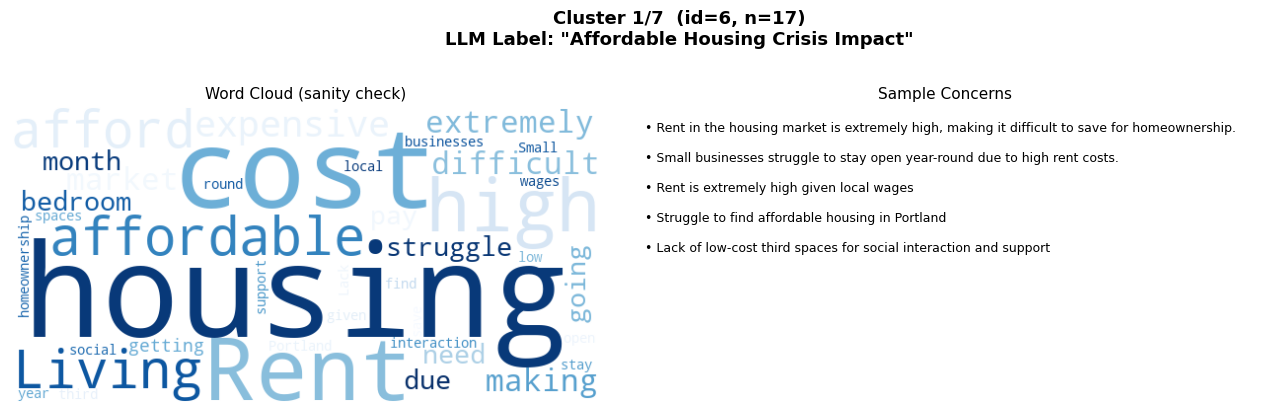

Cluster 2: "Transportation Inefficiency and Accessibility Issues"  (n=16)


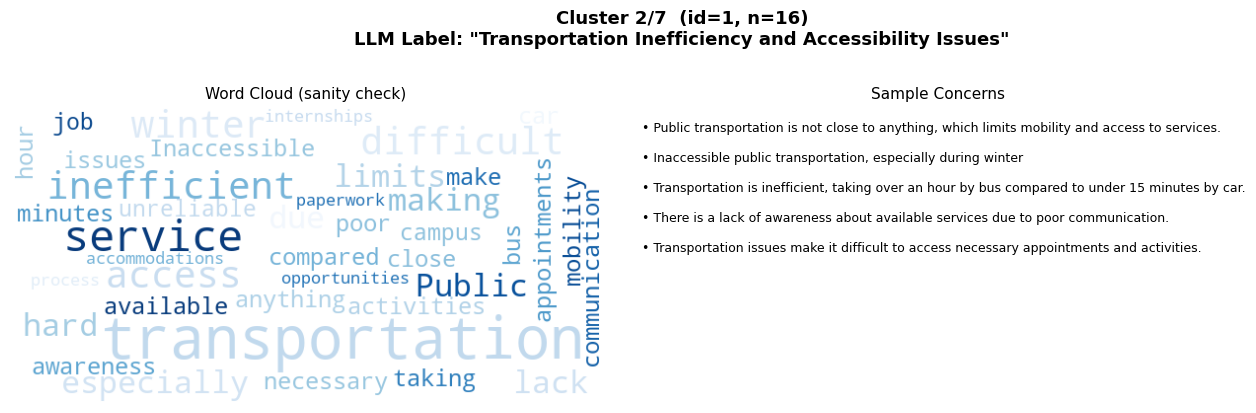

Cluster 3: "Fear and Safety Concerns"  (n=11)


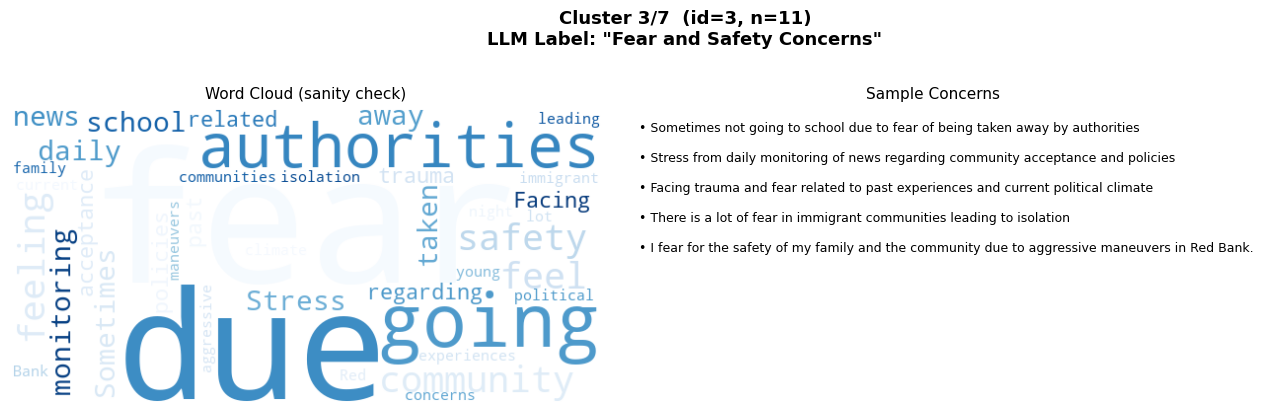

Cluster 4: "Financial Barriers to Youth Opportunities"  (n=10)


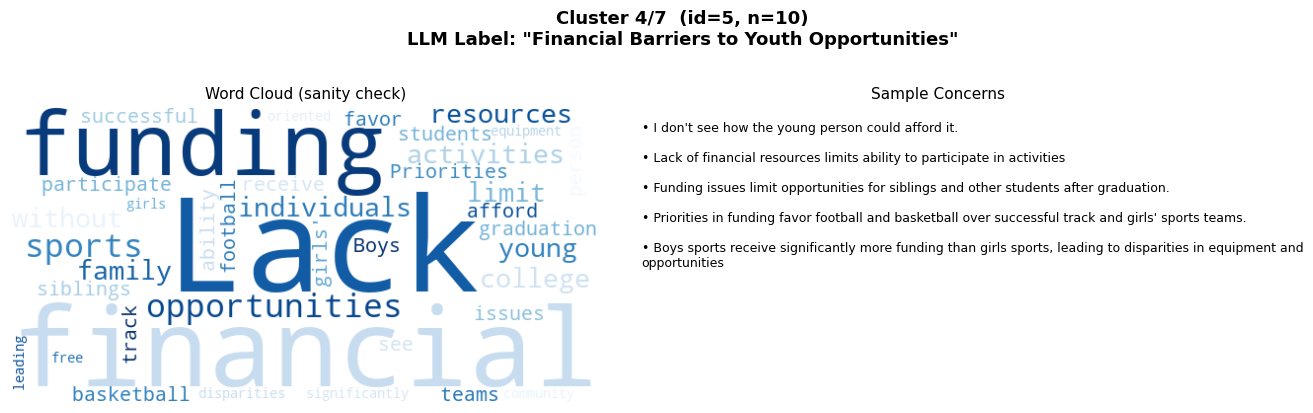

Cluster 5: "Increasing financial strain on residents"  (n=7)


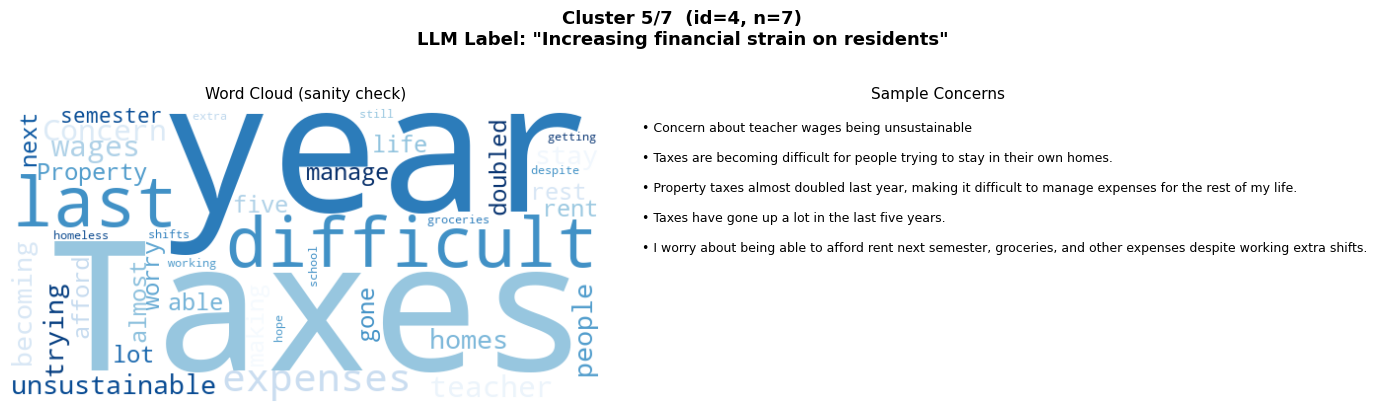

Cluster 6: "Mental Health Access and Support Barriers"  (n=7)


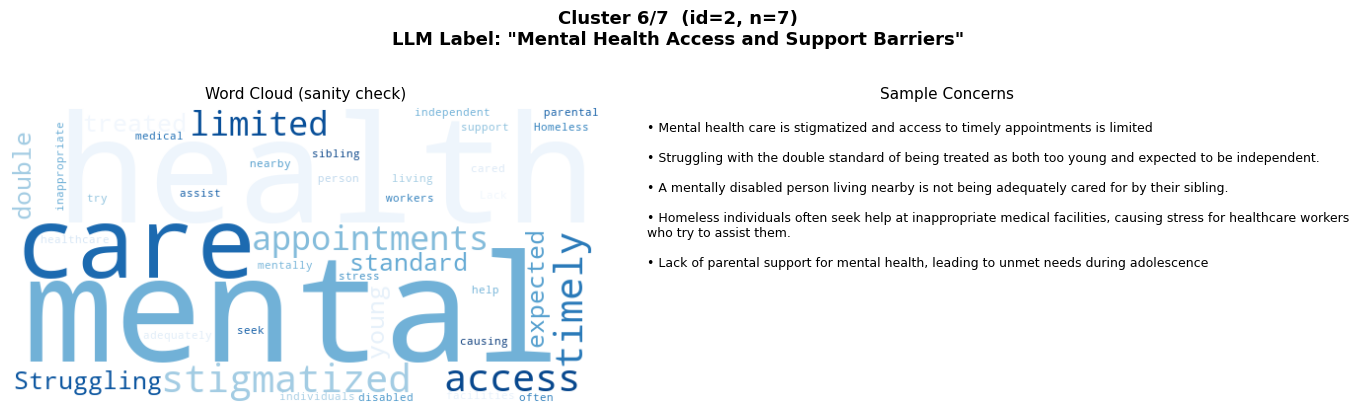

Cluster 7: "Job market barriers and lack of opportunities"  (n=6)


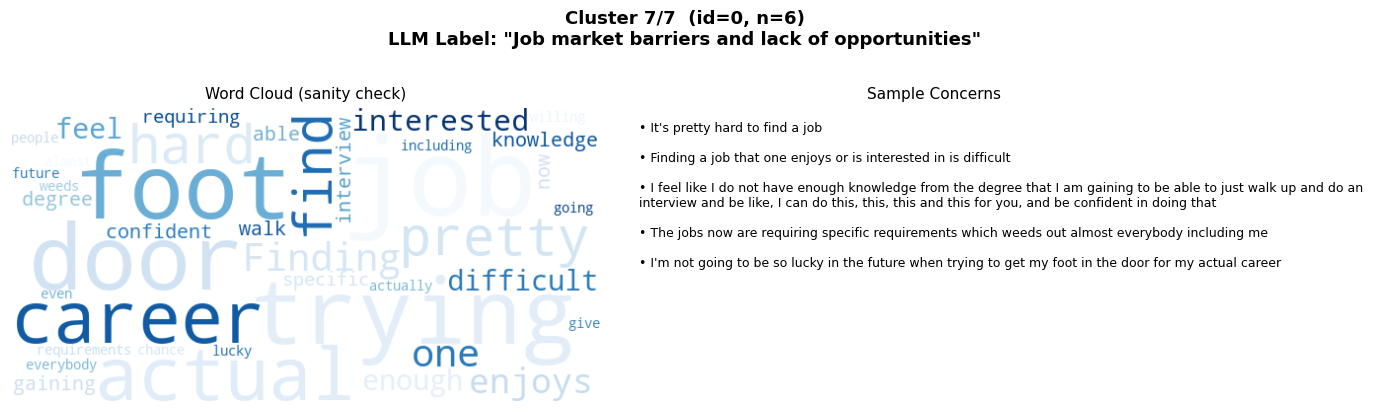


Noise (unclustered): 30 concerns


In [10]:
CLUSTER_NAME_PROMPT = """\
Below are concern statements from members of a community focus group,
all belonging to the same thematic cluster.

CONCERNS:
{concerns}

Give a short, specific 4-7 word label that captures the shared theme.
Return ONLY valid JSON, no explanation:
{{"label": "Housing cost burden on fixed income"}}
"""


def name_cluster(concerns):
    """Ask LLM to generate a short descriptive label for a cluster.

    Uses call_ollama_with_retry — consistent with all other LLM calls.
    """
    prompt = CLUSTER_NAME_PROMPT.format(
        concerns="\n".join(f"- {c}" for c in concerns)
    )
    raw = call_ollama_with_retry(prompt, temperature=0)
    if raw is None:
        return "(label failed)"
    try:
        parsed = json.loads(raw)
        return parsed["label"]
    except Exception:
        return "(label failed)"


def plot_cluster(cluster_id, concerns, llm_label, rank, total):
    """Plot word cloud + sample concerns side by side for one cluster."""
    from wordcloud import STOPWORDS
    combined_text = " ".join(concerns)
    wc = WordCloud(
        width=600, height=300,
        background_color="white",
        stopwords=STOPWORDS,   # filter common words so thematic terms stand out
        max_words=40,
        colormap="Blues",
    ).generate(combined_text)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(
        f"Cluster {rank}/{total}  (id={cluster_id}, n={len(concerns)})\n"
        f"LLM Label: \"{llm_label}\"",
        fontsize=13, fontweight="bold", y=1.02
    )

    axes[0].imshow(wc, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title("Word Cloud (sanity check)", fontsize=11)

    axes[1].axis("off")
    axes[1].set_title("Sample Concerns", fontsize=11)
    sample_text = "\n\n".join(f"• {c}" for c in concerns[:5])
    axes[1].text(
        0.02, 0.95, sample_text,
        transform=axes[1].transAxes,
        fontsize=9, verticalalignment="top",
        wrap=True
    )

    plt.tight_layout()
    plt.savefig(f"cluster_{cluster_id}_all.png", bbox_inches="tight", dpi=150)
    plt.show()


def build_and_display_clusters(df, group_label="All Speakers"):
    """Name all clusters, display word cloud + samples, return summary dict."""
    df_clustered = df[df["cluster"] != -1]
    cluster_ids  = sorted(
        df_clustered["cluster"].unique(),
        key=lambda c: -len(df_clustered[df_clustered["cluster"] == c])
    )

    summary = {}
    print(f"{'='*60}")
    print(f"  CLUSTER RESULTS — {group_label}")
    print(f"{'='*60}\n")

    for rank, cluster_id in enumerate(cluster_ids, 1):
        concerns  = df_clustered[df_clustered["cluster"] == cluster_id]["concern"].tolist()
        llm_label = name_cluster(concerns)
        summary[cluster_id] = {"label": llm_label, "size": len(concerns), "concerns": concerns}
        print(f"Cluster {rank}: \"{llm_label}\"  (n={len(concerns)})")
        plot_cluster(cluster_id, concerns, llm_label, rank, len(cluster_ids))

    noise_n = (df["cluster"] == -1).sum()
    print(f"\nNoise (unclustered): {noise_n} concerns")
    return summary


full_cluster_summary = build_and_display_clusters(df_concerns, group_label="All Speakers")


## 10. 2D UMAP Visualization
Scatter plot of all concerns colored by ALICE class.  
Cluster centroid labels show LLM-generated theme names.  
Blue = ALICE, Orange = Above ALICE, Grey = Cannot Determine.

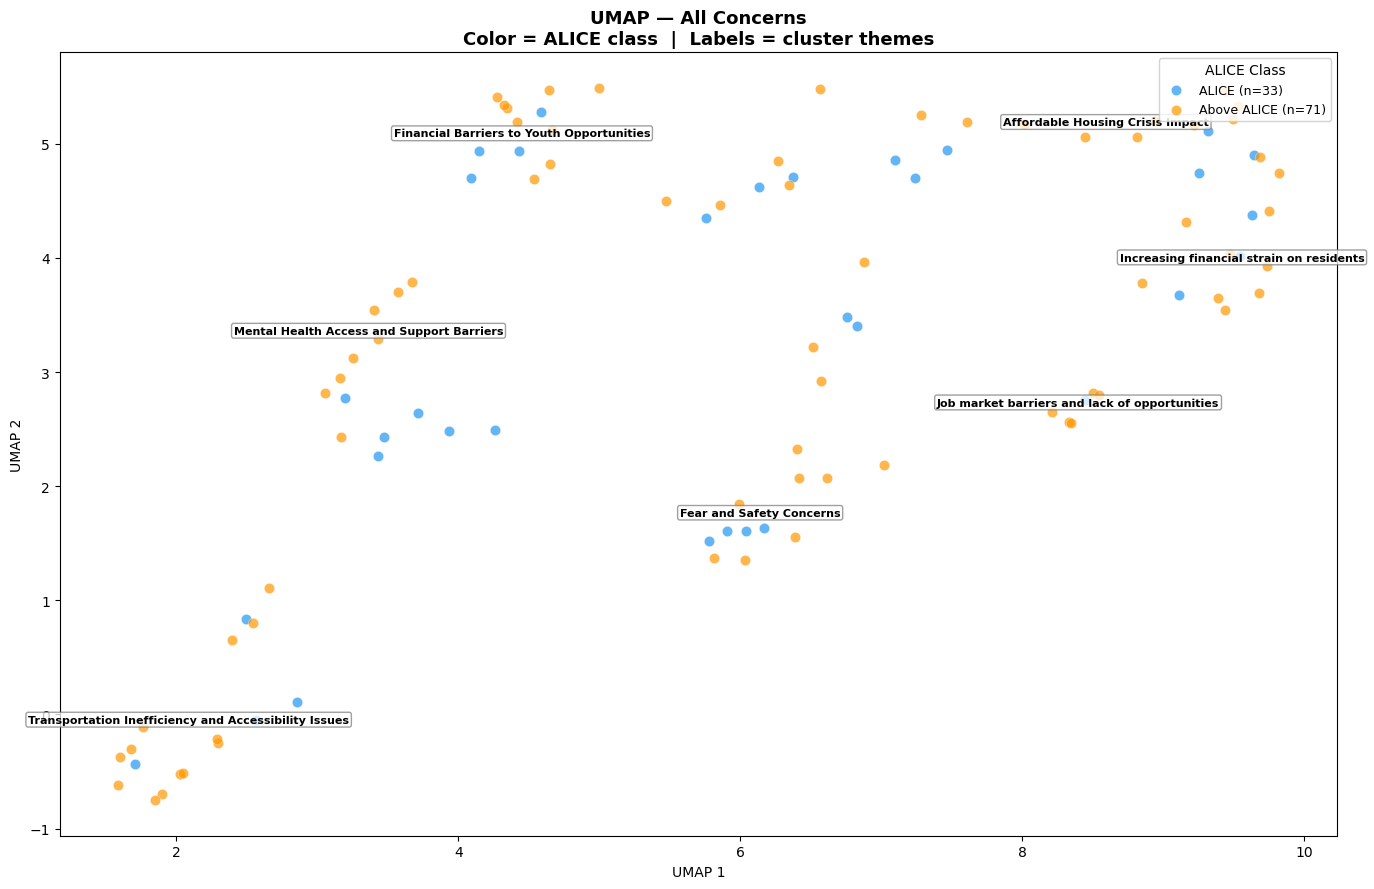

In [11]:
def plot_umap_clusters(df, embeddings_2d, cluster_summary):
    """2D UMAP scatter plot.

    Color = ALICE class (blue=ALICE, orange=Above ALICE, grey=Cannot Determine).
    Cluster centroid labels = LLM-generated theme names.
    """
    labels = df["cluster"].values
    alice_color_map = {
        "ALICE":            "#2196F3",
        "Above ALICE":      "#FF9800",
        "Cannot Determine": "#9E9E9E",
    }

    fig, ax = plt.subplots(figsize=(14, 9))

    # Plot points colored by ALICE class
    for alice_label, color in alice_color_map.items():
        mask = df["alice_class"] == alice_label
        if mask.sum() == 0:
            continue
        ax.scatter(
            embeddings_2d[mask, 0], embeddings_2d[mask, 1],
            c=color, s=55, alpha=0.7, label=f"{alice_label} (n={mask.sum()})",
            edgecolors="white", linewidths=0.3,
        )

    # Annotate cluster centroids with LLM labels
    for cluster_id in sorted(set(labels)):
        if cluster_id == -1:
            continue
        mask  = labels == cluster_id
        cx    = embeddings_2d[mask, 0].mean()
        cy    = embeddings_2d[mask, 1].mean()
        label = cluster_summary.get(cluster_id, {}).get("label", str(cluster_id))
        ax.annotate(
            label, (cx, cy),
            fontsize=8, fontweight="bold", ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75, ec="grey")
        )

    ax.set_title(
        "UMAP — All Concerns\nColor = ALICE class  |  Labels = cluster themes",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.85, title="ALICE Class")
    plt.tight_layout()
    plt.savefig("umap_all_concerns.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_umap_clusters(df_concerns, embeddings_2d, full_cluster_summary)


## 11. Save Outputs

In [13]:
df_concerns.drop(columns=["embedding"], errors="ignore").to_csv(
    "df_concerns_clustered.csv", index=False
)

summary_serializable = {
    str(k): {"label": v["label"], "size": v["size"], "concerns": v["concerns"]}
    for k, v in full_cluster_summary.items()
}
with open("full_cluster_summary.json", "w") as f:
    json.dump(summary_serializable, f, indent=2)

print("Saved:")
print("  df_concerns_clustered.csv  — all concern rows with cluster labels")
print("  embeddings_all.npy         — all embeddings cache")
print("  full_cluster_summary.json  — LLM labels + concerns per cluster")
print("  cluster_*_all.png          — word cloud + sample plots per cluster")
print("  umap_all_concerns.png      — 2D cluster map colored by ALICE class")


Saved:
  df_concerns_clustered.csv  — all concern rows with cluster labels
  embeddings_all.npy         — all embeddings cache
  full_cluster_summary.json  — LLM labels + concerns per cluster
  cluster_*_all.png          — word cloud + sample plots per cluster
  umap_all_concerns.png      — 2D cluster map colored by ALICE class


## 12. Cluster Composition Analysis — ALICE vs. Above ALICE — ALICE vs. Above ALICE
For each cluster, calculate what percentage of concerns came from ALICE vs Above ALICE speakers.  
Clusters skewed heavily toward one group reveal the most distinctive concerns of that group.  
Ranked by dominance — most skewed clusters first.

In [14]:
def compute_cluster_composition(df, cluster_summary):
    """For each cluster, count and percentage-split ALICE vs Above ALICE concerns.

    cluster_summary keys are integers (from df['cluster'].unique()).
    When the summary is loaded from JSON, keys become strings — this function
    normalises all lookups to str(cluster_id) to handle both cases safely.

    Returns a dataframe ranked by skew — the most group-distinctive clusters first.
    """
    rows = []
    df_clustered = df[df["cluster"] != -1]
    # Normalise summary keys to strings to handle post-JSON-reload case
    summary_str_keys = {str(k): v for k, v in cluster_summary.items()}

    for cluster_id in df_clustered["cluster"].unique():
        info        = summary_str_keys.get(str(cluster_id), {"label": str(cluster_id), "size": 0})
        cluster_df  = df_clustered[df_clustered["cluster"] == cluster_id]
        n_total     = len(cluster_df)
        n_alice     = (cluster_df["alice_class"] == "ALICE").sum()
        n_above     = (cluster_df["alice_class"] == "Above ALICE").sum()
        n_unknown   = n_total - n_alice - n_above
        pct_alice   = round(100 * n_alice / n_total, 1) if n_total > 0 else 0
        pct_above   = round(100 * n_above / n_total, 1) if n_total > 0 else 0
        spkrs_alice = cluster_df[cluster_df["alice_class"] == "ALICE"]["speaker_id"].nunique()
        spkrs_above = cluster_df[cluster_df["alice_class"] == "Above ALICE"]["speaker_id"].nunique()
        skew        = abs(pct_alice - pct_above)
        dominant    = "ALICE" if pct_alice >= pct_above else "Above ALICE"

        rows.append({
            "cluster_id":    cluster_id,
            "label":         info.get("label", str(cluster_id)),
            "n_total":        n_total,
            "n_alice":        n_alice,
            "n_above":        n_above,
            "n_unknown":      n_unknown,
            "pct_alice":      pct_alice,
            "pct_above":      pct_above,
            "spkrs_alice":    spkrs_alice,
            "spkrs_above":    spkrs_above,
            "skew":           skew,
            "dominant_group": dominant,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("skew", ascending=False)
        .reset_index(drop=True)
    )


def print_composition(composition):
    """Print cluster composition ranked by dominance."""
    print("=" * 100)
    print("  CLUSTER COMPOSITION — ALICE vs. ABOVE ALICE")
    print("  Ranked by skew (most group-distinctive clusters first)")
    print("=" * 100)
    print(f"{'Label':<45} {'Total':>6} {'ALICE%':>7} {'Above%':>7} {'Dominant':>12} {'Spkrs A/B':>10}")
    print("-" * 100)
    for _, row in composition.iterrows():
        print(
            f"{row['label'][:44]:<45} "
            f"{row['n_total']:>6} "
            f"{row['pct_alice']:>7.1f}% "
            f"{row['pct_above']:>6.1f}% "
            f"{row['dominant_group']:>12} "
            f"{row['spkrs_alice']:>4}/{row['spkrs_above']:<4}"
        )
    print("=" * 100)


composition = compute_cluster_composition(df_concerns, full_cluster_summary)
print_composition(composition)
composition.to_csv("cluster_composition.csv", index=False)
print("\ncluster_composition.csv saved.")


  CLUSTER COMPOSITION — ALICE vs. ABOVE ALICE
  Ranked by skew (most group-distinctive clusters first)
Label                                          Total  ALICE%  Above%     Dominant  Spkrs A/B
----------------------------------------------------------------------------------------------------
Mental Health Access and Support Barriers          7     0.0%  100.0%  Above ALICE    0/4   
Job market barriers and lack of opportunitie       6    16.7%   83.3%  Above ALICE    1/1   
Affordable Housing Crisis Impact                  17    17.6%   82.4%  Above ALICE    2/3   
Transportation Inefficiency and Accessibilit      16    18.8%   81.2%  Above ALICE    3/5   
Increasing financial strain on residents           7    28.6%   71.4%  Above ALICE    1/2   
Fear and Safety Concerns                          11    36.4%   63.6%  Above ALICE    1/3   
Financial Barriers to Youth Opportunities         10    40.0%   60.0%  Above ALICE    3/3   

cluster_composition.csv saved.


## 12. LLM Comparative Summary
Pass the cluster composition results to the LLM to generate a human-readable narrative.  
This is the most actionable output for United Way stakeholders.

In [15]:
COMPARISON_SUMMARY_PROMPT = """\
You are analyzing results from a community focus group study in Southern Maine.
Below are the main concern clusters for two groups: ALICE (financially struggling)
and Above ALICE (financially stable).

ALICE DOMINANT CLUSTERS (concerns concentrated among ALICE speakers):
{alice_clusters}

ABOVE ALICE DOMINANT CLUSTERS (concerns concentrated among Above ALICE speakers):
{above_clusters}

SHARED CLUSTERS (concerns raised by both groups):
{shared_clusters}

Write a clear, concise narrative (3-5 paragraphs) for a United Way audience that:
1. Summarizes the most pressing concerns unique to ALICE community members
2. Summarizes the most pressing concerns unique to Above ALICE community members
3. Identifies concerns shared by both groups and notes any differences in framing
4. Highlights 2-3 actionable implications for United Way program priorities

Write in plain language. Be specific. Avoid jargon.
"""


def build_cluster_list(composition, full_cluster_summary, group, top_n=5):
    """Build a formatted string of top clusters for a given dominant group.

    Uses str(cluster_id) for summary lookups so integer and post-JSON-reload
    string keys both work correctly.
    """
    summary_str_keys = {str(k): v for k, v in full_cluster_summary.items()}
    group_clusters   = composition[composition["dominant_group"] == group].head(top_n)
    lines = []
    for _, row in group_clusters.iterrows():
        pct  = row["pct_alice"] if group == "ALICE" else row["pct_above"]
        exs  = summary_str_keys.get(str(row["cluster_id"]), {}).get("concerns", [])[:2]
        lines.append(f"- {row['label']} ({pct:.0f}% from {group})")
        for ex in exs:
            lines.append(f"  e.g. '{ex}'")
    return "\n".join(lines) if lines else "None identified"


def build_shared_list(composition, full_cluster_summary, skew_threshold=20, top_n=3):
    """Build a formatted string of clusters shared by both groups (low skew)."""
    shared = composition[composition["skew"] <= skew_threshold].head(top_n)
    lines  = []
    for _, row in shared.iterrows():
        lines.append(f"- {row['label']} (ALICE: {row['pct_alice']:.0f}%, Above ALICE: {row['pct_above']:.0f}%)")
    return "\n".join(lines) if lines else "None identified"


def generate_comparative_summary(composition, full_cluster_summary):
    """Ask LLM to generate a narrative comparison of ALICE vs Above ALICE concerns."""
    prompt = COMPARISON_SUMMARY_PROMPT.format(
        alice_clusters  = build_cluster_list(composition, full_cluster_summary, "ALICE"),
        above_clusters  = build_cluster_list(composition, full_cluster_summary, "Above ALICE"),
        shared_clusters = build_shared_list(composition, full_cluster_summary),
    )
    raw = call_ollama_with_retry(prompt, temperature=0.3)
    return raw if raw else "(Summary generation failed)"


summary_text = generate_comparative_summary(composition, full_cluster_summary)

print("=" * 80)
print("  COMPARATIVE SUMMARY: ALICE vs. ABOVE ALICE CONCERNS")
print("=" * 80)
print(summary_text)

with open("comparative_summary.txt", "w") as f:
    f.write(summary_text)

print("\nAll outputs saved:")
print("  df_concerns_clustered.csv       — all concern rows with cluster + ALICE labels")
print("  embeddings_all.npy              — embeddings cache")
print("  full_cluster_summary.json       — LLM cluster labels + concerns")
print("  cluster_composition.csv         — ALICE vs Above ALICE breakdown per cluster")
print("  umap_all_concerns.png           — 2D map colored by ALICE class")
print("  blind_clustering_validation.png — quantitative separation evidence")
print("  comparative_summary.txt         — LLM narrative for stakeholders")


  COMPARATIVE SUMMARY: ALICE vs. ABOVE ALICE CONCERNS
{ }

All outputs saved:
  df_concerns_clustered.csv       — all concern rows with cluster + ALICE labels
  embeddings_all.npy              — embeddings cache
  full_cluster_summary.json       — LLM cluster labels + concerns
  cluster_composition.csv         — ALICE vs Above ALICE breakdown per cluster
  umap_all_concerns.png           — 2D map colored by ALICE class
  blind_clustering_validation.png — quantitative separation evidence
  comparative_summary.txt         — LLM narrative for stakeholders


## 13. Blind Clustering Validation
Quantitative evidence that the ALICE / Above ALICE separation observed in the UMAP
is driven by real semantic differences in the concern text — not by pipeline bias.

**Three complementary metrics:**
- **Cluster purity** — weighted average of the dominant group's share per cluster (50% = random baseline)
- **Adjusted Rand Index + permutation test** — does cluster assignment correlate with ALICE label beyond chance?
- **UMAP silhouette score** — are ALICE and Above ALICE points in spatially distinct regions of the 2D map?

All three metrics use labels only *after* clustering — labels are never used to create the clusters.


  BLIND CLUSTERING VALIDATION
  ALICE labels applied AFTER clustering — never used to create clusters
  Cluster purity     : 77.0%  (50% = random baseline)
  ARI (real)         : -0.0007
  ARI null mean      : -0.0006 ± 0.0124
  ARI p-value        : 0.4430  (✗ not significant)
  UMAP silhouette    : -0.0323  (positive = spatial separation)

Interpretation guide:
  Purity > 65% + p < 0.05 + silhouette > 0  →  separation is real in the data
  Purity ~50%  or  p > 0.05                  →  pipeline bias likely inflating results


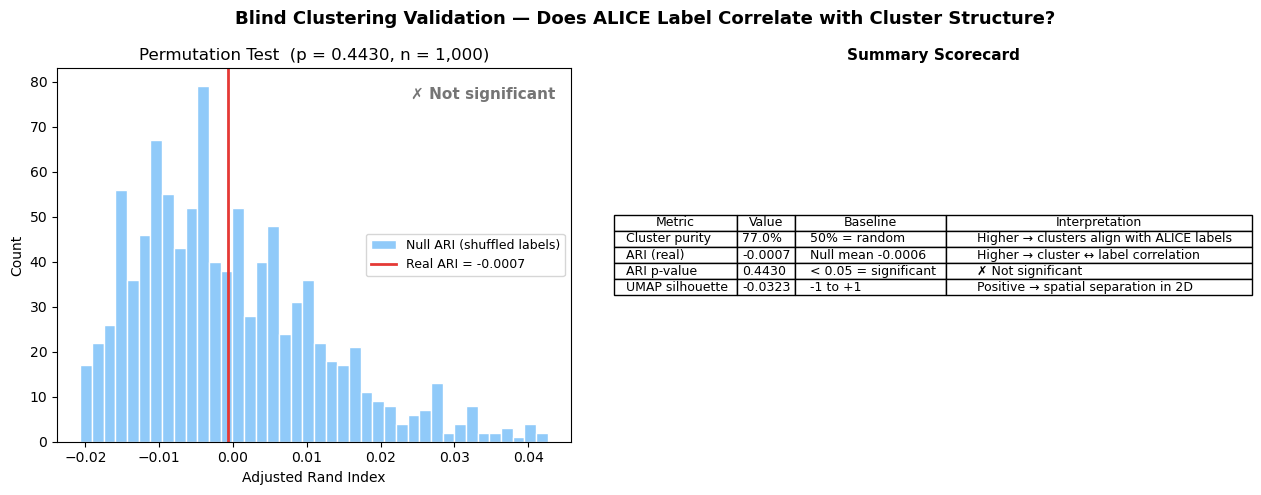


blind_clustering_validation.png saved.


In [18]:
def cluster_purity(composition):
    """Weighted average of the dominant group's share per cluster.

    50% = random baseline (every cluster is 50/50)
    100% = perfect separation (every cluster is pure)
    """
    weights      = composition["n_total"].values
    dominant_pct = composition[["pct_alice", "pct_above"]].max(axis=1).values
    purity       = float(np.average(dominant_pct, weights=weights))
    return purity


def ari_with_permutation_test(df, n_permutations=1000):
    """Adjusted Rand Index between cluster labels and ALICE labels, with permutation test.

    Builds a null distribution by shuffling ALICE labels n_permutations times.
    p-value = fraction of null ARIs >= real ARI.
    p < 0.05 means the cluster-ALICE correlation is unlikely to be random chance.
    """
    valid        = df[df["alice_class"].isin(["ALICE", "Above ALICE"])].copy()
    alice_num    = valid["alice_class"].map({"ALICE": 0, "Above ALICE": 1}).values
    clusters     = valid["cluster"].values

    real_ari  = adjusted_rand_score(alice_num, clusters)

    rng       = np.random.default_rng(42)
    null_aris = np.array([
        adjusted_rand_score(rng.permutation(alice_num), clusters)
        for _ in range(n_permutations)
    ])

    p_value = float((null_aris >= real_ari).mean())
    return real_ari, null_aris, p_value


def umap_separation_score(df, embeddings_2d):
    """Silhouette score treating ALICE label as the 'cluster' in 2D UMAP space.

    +1 = ALICE and Above ALICE occupy completely different 2D regions
     0 = groups overlap completely
    -1 = inverted (shouldn't occur here)
    """
    valid_mask = df["alice_class"].isin(["ALICE", "Above ALICE"])
    coords     = embeddings_2d[valid_mask.values]
    labels     = df.loc[valid_mask, "alice_class"].map(
        {"ALICE": 0, "Above ALICE": 1}
    ).values
    if len(set(labels)) < 2:
        return float("nan")   # can't compute with only one group
    return float(silhouette_score(coords, labels, metric="euclidean"))


def plot_validation(null_aris, real_ari, p_value, purity, separation):
    """Two-panel figure: permutation null distribution + summary scorecard."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Blind Clustering Validation — Does ALICE Label Correlate with Cluster Structure?",
        fontsize=13, fontweight="bold"
    )

    # Left panel: permutation null distribution
    ax = axes[0]
    ax.hist(null_aris, bins=40, color="#90CAF9", edgecolor="white", label="Null ARI (shuffled labels)")
    ax.axvline(real_ari, color="#E53935", linewidth=2, label=f"Real ARI = {real_ari:.4f}")
    ax.set_xlabel("Adjusted Rand Index")
    ax.set_ylabel("Count")
    ax.set_title(f"Permutation Test  (p = {p_value:.4f}, n = {len(null_aris):,})")
    ax.legend(fontsize=9)
    sig_label = "✓ Significant" if p_value < 0.05 else "✗ Not significant"
    ax.text(0.97, 0.95, sig_label, transform=ax.transAxes,
            ha="right", va="top", fontsize=11,
            color="#E53935" if p_value < 0.05 else "#757575",
            fontweight="bold")

    # Right panel: scorecard
    ax2 = axes[1]
    ax2.axis("off")
    rows_data = [
        ["Metric", "Value", "Baseline", "Interpretation"],
        ["Cluster purity",
         f"{purity:.1f}%",
         "50% = random",
         "Higher → clusters align with ALICE labels"],
        ["ARI (real)",
         f"{real_ari:.4f}",
         f"Null mean {null_aris.mean():.4f}",
         "Higher → cluster ↔ label correlation"],
        ["ARI p-value",
         f"{p_value:.4f}",
         "< 0.05 = significant",
         sig_label],
        ["UMAP silhouette",
         f"{separation:.4f}" if not (separation != separation) else "N/A",
         "-1 to +1",
         "Positive → spatial separation in 2D"],
    ]
    tbl = ax2.table(
        cellText=rows_data[1:],
        colLabels=rows_data[0],
        cellLoc="left",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.auto_set_column_width(col=list(range(4)))
    ax2.set_title("Summary Scorecard", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.savefig("blind_clustering_validation.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Run all three metrics ─────────────────────────────────────────────────────
purity                         = cluster_purity(composition)
real_ari, null_aris, p_value   = ari_with_permutation_test(df_concerns)
separation                     = umap_separation_score(df_concerns, embeddings_2d)

print("=" * 60)
print("  BLIND CLUSTERING VALIDATION")
print("  ALICE labels applied AFTER clustering — never used to create clusters")
print("=" * 60)
print(f"  Cluster purity     : {purity:.1f}%  (50% = random baseline)")
print(f"  ARI (real)         : {real_ari:.4f}")
print(f"  ARI null mean      : {null_aris.mean():.4f} ± {null_aris.std():.4f}")
print(f"  ARI p-value        : {p_value:.4f}  ({'✓ significant' if p_value < 0.05 else '✗ not significant'})")
print(f"  UMAP silhouette    : {separation:.4f}  (positive = spatial separation)")
print()
print("Interpretation guide:")
print("  Purity > 65% + p < 0.05 + silhouette > 0  →  separation is real in the data")
print("  Purity ~50%  or  p > 0.05                  →  pipeline bias likely inflating results")

plot_validation(null_aris, real_ari, p_value, purity, separation)
print("\nblind_clustering_validation.png saved.")
